## Preprocessing of SRI24 atlas (used by Brain Tumor Segmentation (BraTS) Challenge)

## Skull striped image which is needed for registration 

In [1]:
import os
os.environ['MKL_THREADING_LAYER'] = 'GNU'
import shutil
import sys
import subprocess
import pandas as pd
import nibabel as nib
import ants
import copy

import numpy as np

 This function **get_ImageBasicInfo** takes a file path to an MRI image, loads it using **nibabel**, and prints out basic information about the image such as its **shape, zoom levels, orientation, and affine transformation matrix**.

In [2]:
def get_ImageBasicInfo(t1SRIPath):
    checkSRIT1 = nib.load(t1SRIPath)
    print(f' atlas shape: {checkSRIT1.shape}, atlas header.get_zooms(): {checkSRIT1.header.get_zooms()}, orientation: {nib.orientations.aff2axcodes(checkSRIT1.affine)},\
    affine\n: {checkSRIT1.affine}')


##### This block defines the directory paths and file paths for the SRI24-atlas (T1-weighted MRI image).


In [3]:
rdir = '../data/sri24_spm8_selected/'
srdir = '../data/sri24_spm8_selected/'
T1_sri24 = os.path.join(rdir, 'T1.nii')
T1_sri24


'../data/sri24_spm8_selected/T1.nii'

##### Displaying Image Information and plotting

 atlas shape: (240, 240, 155, 1), atlas header.get_zooms(): (1.0, 1.0, 1.0, 0.0), orientation: ('R', 'A', 'S'),    affine
: [[   1.    0.    0. -120.]
 [   0.    1.    0. -129.]
 [   0.    0.    1.  -68.]
 [   0.    0.    0.    1.]]


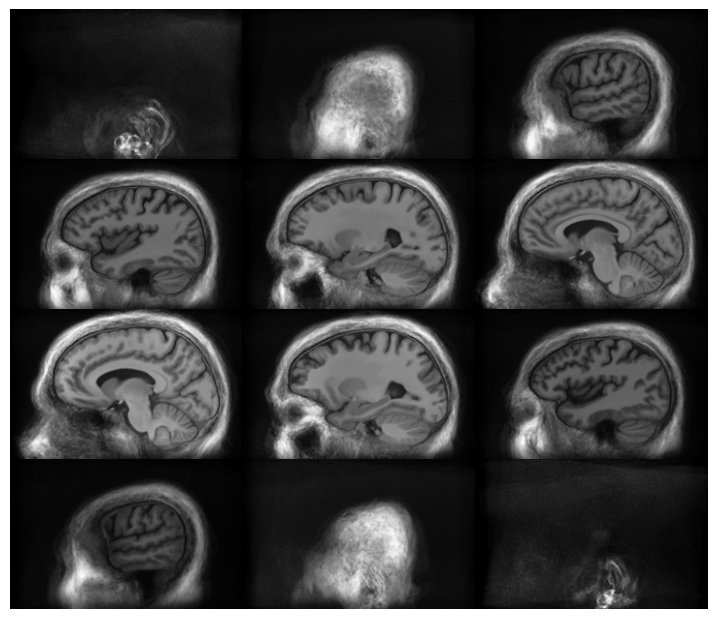

In [4]:
get_ImageBasicInfo(T1_sri24)
ants.image_read(T1_sri24).plot()
print('\n')


### Correcting atlas's origin matching with BraTS21 subjects

This block reads the T1-weighted MRI image, reorients it to "RAI", sets a new origin, and writes the modified image to a new file.

In [5]:
T1_sri24_Img = ants.image_read(T1_sri24, reorient="RAI")
brats_origin = (-0.0, -239.0, 0.0)
# brats_direction = np.array([[1., 0., 0.],
#        [0., 1., 0.],
#        [0., 0., 1.]])


T1_sri24_Img_norig = ants.from_numpy(copy.deepcopy(T1_sri24_Img.numpy()).astype(np.float32), origin=brats_origin,\
                                      spacing=copy.deepcopy(T1_sri24_Img.spacing), direction=copy.deepcopy(T1_sri24_Img.direction)) 

ants.image_write(T1_sri24_Img_norig, '../data/sri24_spm8_selected/T1_sri24_BraTS.nii.gz', ri = True)


ANTsImage (RAI)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (240, 240, 155)
	 Spacing    : (1.0, 1.0, 1.0)
	 Origin     : (-0.0, -239.0, 0.0)
	 Direction  : [1. 0. 0. 0. 1. 0. 0. 0. 1.]

#### Displaying image information of the corrected image and comparing it with a sample subject from BraTS dataset

In [15]:
print(T1_sri24_Img_norig, '\n')
print('\n### Image information of a Brats subject###\n')
print(ants.image_read('../data/BraTS2021_00078/BraTS2021_00078_t1ce.nii.gz'),'\nLPS\n\n', '\n\nOriginal####\n\n', ants.image_read(T1_sri24))

ANTsImage (RAI)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (240, 240, 155)
	 Spacing    : (1.0, 1.0, 1.0)
	 Origin     : (-0.0, -239.0, 0.0)
	 Direction  : [1. 0. 0. 0. 1. 0. 0. 0. 1.]
 


### Image information of a Brats subject###

ANTsImage (RAI)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (240, 240, 155)
	 Spacing    : (1.0, 1.0, 1.0)
	 Origin     : (-0.0, -239.0, 0.0)
	 Direction  : [1. 0. 0. 0. 1. 0. 0. 0. 1.]
 
LPS

 

Original####

 ANTsImage (LPI)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (240, 240, 155)
	 Spacing    : (1.0, 1.0, 1.0)
	 Origin     : (120.0, 129.0, -68.0)
	 Direction  : [-1.  0.  0.  0. -1.  0.  0.  0.  1.]



##### Define path of the atlas for skull stripping

In [16]:
# sr24_bratsPath=os.path.abspath(os.path.join(srdir, 'T1_sri24_BraTS.nii.gz'))
# sr24_bratsDestPath = os.path.abspath(os.path.join(srdir, 'T1_sri24_BraTS_bet.nii.gz'))

sr24_bratsPath=os.path.join(srdir, 'T1_sri24_BraTS.nii.gz')
sr24_bratsDestPath = os.path.join(srdir, 'T1_sri24_BraTS_bet.nii.gz')
sr24_bratsPath, sr24_bratsDestPath

('../data/sri24_spm8_selected/T1_sri24_BraTS.nii.gz',
 '../data/sri24_spm8_selected/T1_sri24_BraTS_bet.nii.gz')

##### Perform skull stripping using hd-bet

In [9]:
#!hd-bet -i {sr24_bratsPath} -o {sr24_bratsDestPath} -device cpu --disable_tta --save_bet_mask
subprocess.run(['hd-bet', '-i', sr24_bratsPath, '-o', sr24_bratsDestPath, '-device', 'cpu', '--disable_tta', '--save_bet_mask'])  


/home/har010/miniconda3/envs/3d-image-registration-segmentation/lib/python3.11/site-packages/nnunetv2/inference/predict_from_raw_data.py:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experiment


########################
If you are using hd-bet, please cite the following papers:

Isensee F, Schell M, Tursunova I, Brugnara G, Bonekamp D, Neuberger U, Wick A, Schlemmer HP, Heiland S, Wick W, Bendszus M, Maier-Hein KH, Kickingereder P. Automated brain extraction of multi-sequence MRI using artificial neural networks. arXiv preprint arXiv:1901.11341, 2019.

Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
########################

perform_everything_on_device=True is only supported for cuda devices! Setting this to False
There are 1 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 1 cases that I would like to predict

Predicting T1_sri24_BraTS_bet_bet.nii.gz:
perform_everything_on_device: False


100%|██████████| 12/12 [01:39<00:00,  8.33s/it]


sending off prediction to background worker for resampling and export
done with T1_sri24_BraTS_bet_bet.nii.gz


CompletedProcess(args=['hd-bet', '-i', '../data/sri24_spm8_selected/T1_sri24_BraTS.nii.gz', '-o', '../data/sri24_spm8_selected/T1_sri24_BraTS_bet.nii.gz', '-device', 'cpu', '--disable_tta', '--save_bet_mask'], returncode=0)

##### Rename the skull stripped image mask

In [10]:
#!mv {os.path.join(srdir,"T1_sri24_BraTS_bet_bet.nii.gz")} {os.path.join(srdir,"T1_sri24_BraTS_bet_mask.nii.gz")} 
subprocess.run(['mv', os.path.join(srdir,"T1_sri24_BraTS_bet_bet.nii.gz"), os.path.join(srdir,"T1_sri24_BraTS_bet_mask.nii.gz")])

CompletedProcess(args=['mv', '../data/sri24_spm8_selected/T1_sri24_BraTS_bet_bet.nii.gz', '../data/sri24_spm8_selected/T1_sri24_BraTS_bet_mask.nii.gz'], returncode=0)

##### Display information and plots for the original, and skull stripped and its mask images

### Input image ####

 atlas shape: (240, 240, 155), atlas header.get_zooms(): (1.0, 1.0, 1.0), orientation: ('L', 'P', 'S'),    affine
: [[ -1.   0.   0.  -0.]
 [  0.  -1.   0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]


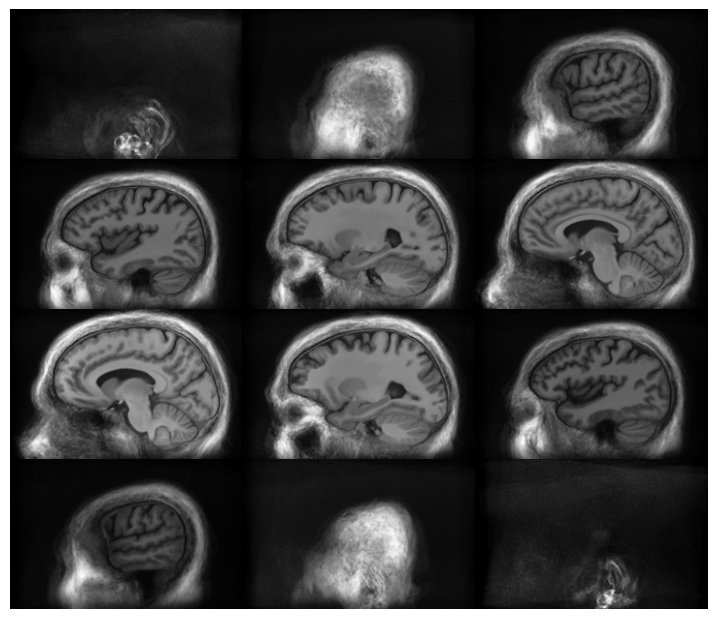



### Skull stripped image ####

 atlas shape: (240, 240, 155), atlas header.get_zooms(): (1.0, 1.0, 1.0), orientation: ('L', 'P', 'S'),    affine
: [[ -1.   0.   0.  -0.]
 [  0.  -1.   0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]


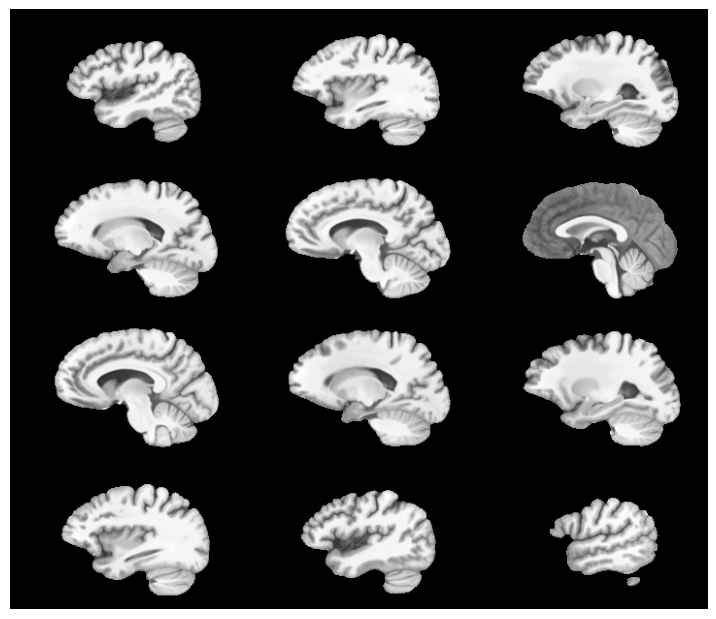



### Mask of the skull stripped image ####

 atlas shape: (240, 240, 155), atlas header.get_zooms(): (1.0, 1.0, 1.0), orientation: ('L', 'P', 'S'),    affine
: [[ -1.   0.   0.  -0.]
 [  0.  -1.   0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]


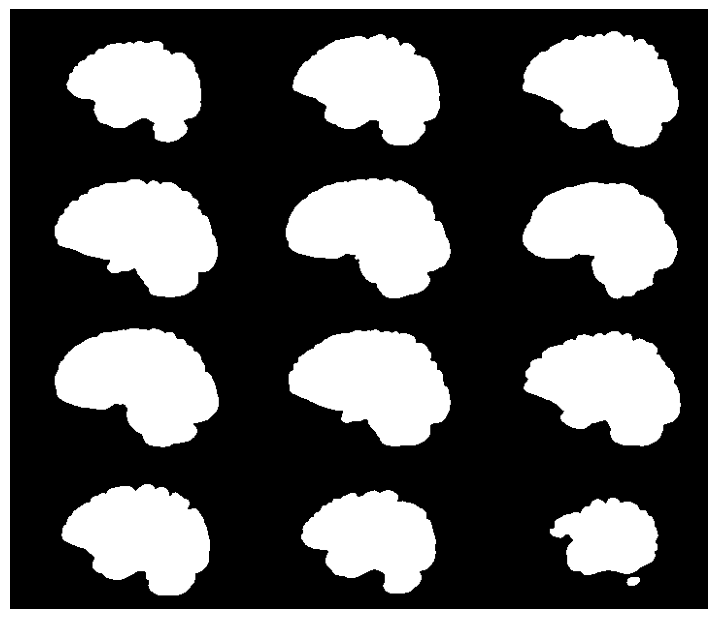

In [17]:
print('### Input image ####\n')
get_ImageBasicInfo(sr24_bratsPath)
ants.image_read(sr24_bratsPath).plot()
print('\n')


print('### Skull stripped image ####\n')
get_ImageBasicInfo(os.path.join(srdir, 'T1_sri24_BraTS_bet.nii.gz'))
ants.image_read(os.path.join(srdir, 'T1_sri24_BraTS_bet.nii.gz')).plot()
print('\n')


print('### Mask of the skull stripped image ####\n')
get_ImageBasicInfo(os.path.join(srdir, 'T1_sri24_BraTS_bet_mask.nii.gz'))
ants.image_read(os.path.join(srdir, 'T1_sri24_BraTS_bet_mask.nii.gz')).plot()
print('\n')

##### Displaying image information of an image and checking whether the information changes after reorientation

In [19]:
print(ants.image_read(os.path.join(srdir,"T1_sri24_BraTS_bet_mask.nii.gz")))

print("\n\n\n  After reorientation \n\n\n")

print(ants.image_read(os.path.join(srdir,"T1_sri24_BraTS_bet_mask.nii.gz"), reorient = 'RAI'))

ANTsImage (RAI)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (240, 240, 155)
	 Spacing    : (1.0, 1.0, 1.0)
	 Origin     : (0.0, -239.0, 0.0)
	 Direction  : [1. 0. 0. 0. 1. 0. 0. 0. 1.]




  After reorientation 



ANTsImage (RAI)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (240, 240, 155)
	 Spacing    : (1.0, 1.0, 1.0)
	 Origin     : (0.0, -239.0, 0.0)
	 Direction  : [1. 0. 0. 0. 1. 0. 0. 0. 1.]

